<a href="https://colab.research.google.com/github/bestianello88/ANALISI/blob/main/PREDIZIONE_CO2_PROGETTO_FINALE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TRASFORMAZIONE DEI DATI PER IL MACHINE LEARNING**



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 35 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  27 non-null     object 
 1   1990     27 non-null     float64
 2   1991     27 non-null     float64
 3   1992     27 non-null     float64
 4   1993     27 non-null     float64
 5   1994     27 non-null     float64
 6   1995     27 non-null     float64
 7   1996     27 non-null     float64
 8   1997     27 non-null     float64
 9   1998     27 non-null     float64
 10  1999     27 non-null     float64
 11  2000     27 non-null     float64
 12  2001     27 non-null     float64
 13  2002     27 non-null     float64
 14  2003     27 non-null     float64
 15  2004     27 non-null     float64
 16  2005     27 non-null     float64
 17  2006     27 non-null     float64
 18  2007     27 non-null     float64
 19  2008     27 non-null     float64
 20  2009     27 non-null     float64
 21  2010     27 non-

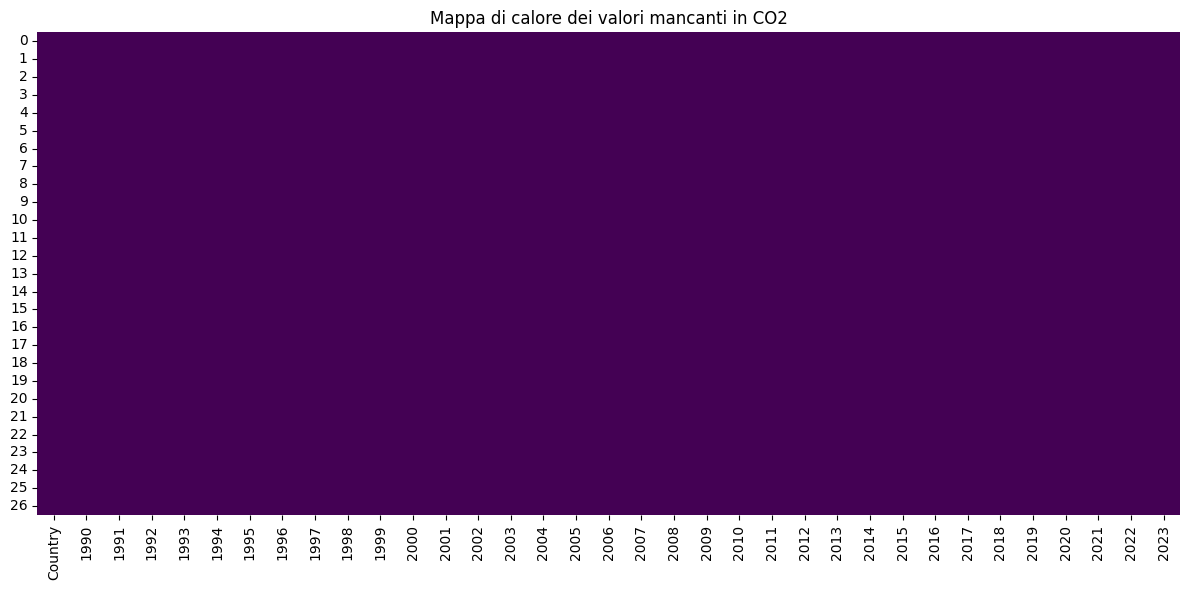

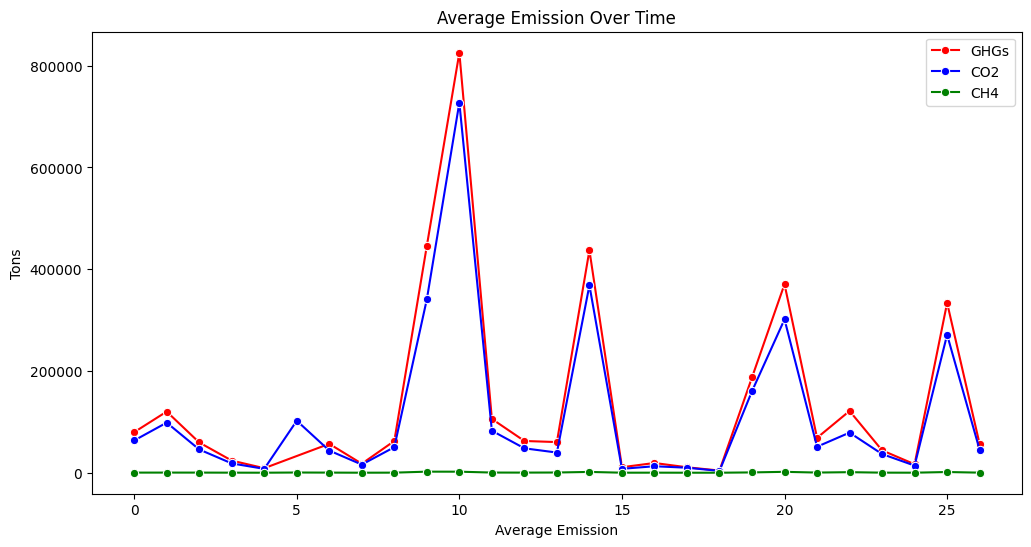

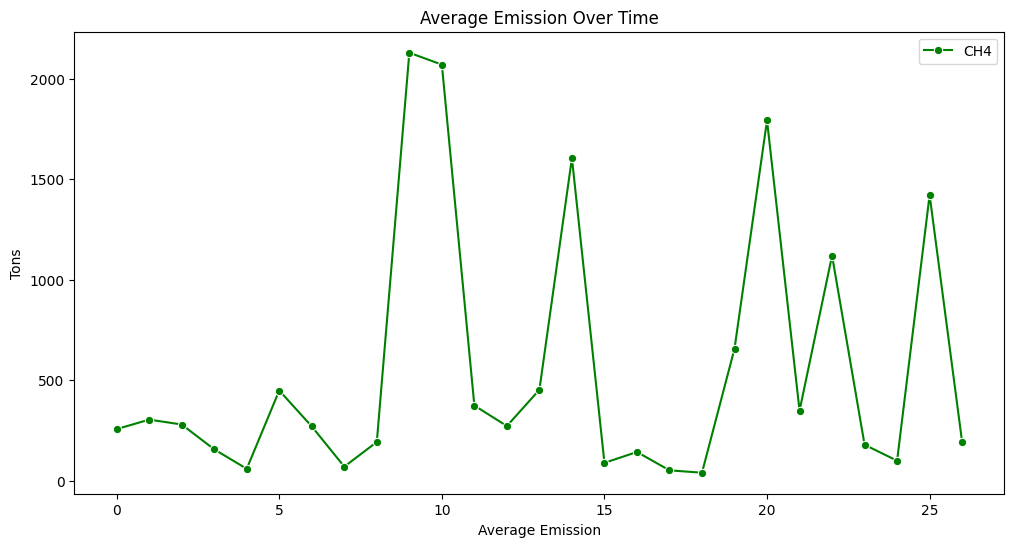

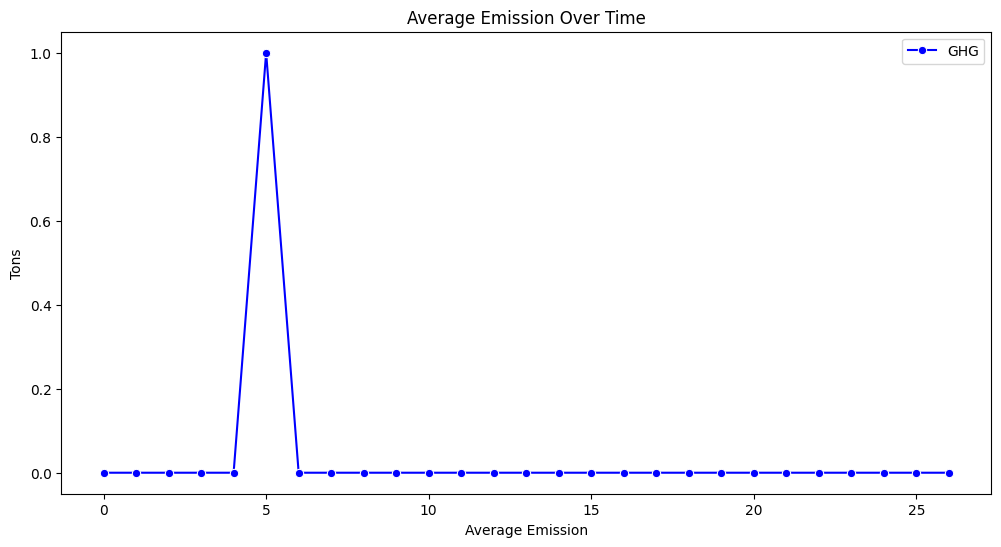

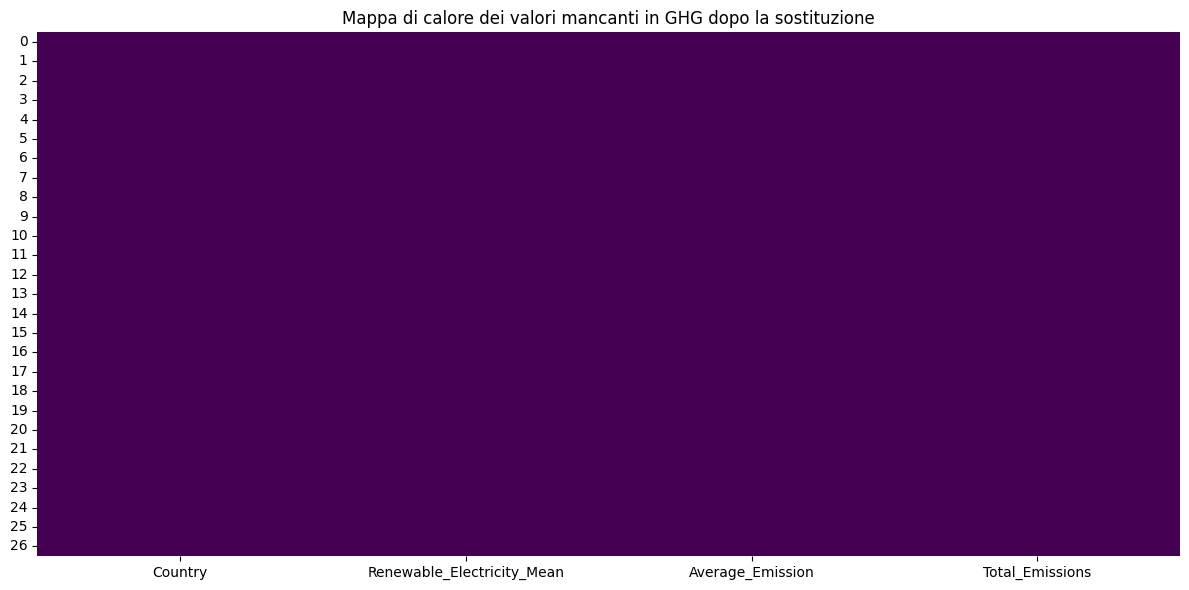

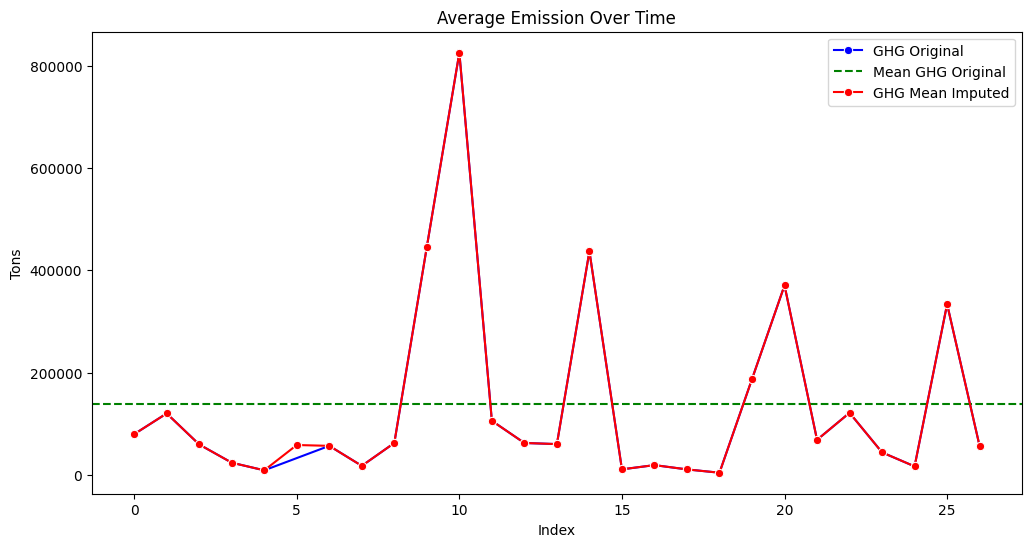

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from google.colab import drive

# PROGRAMMA CHE MI SOSTITUISCE AUTOMATICAMENTE I MISSING VALUES SU OGNI COLONNA CON LA MEDIA MOBILE

def fill_missing_values_with_moving_average(df, window_size=12):
  temp_df = df.copy() # Work on a copy to avoid modifying original df outside the function if not intended
  for column in temp_df.columns :
    # Only try to fill if the column is numeric and has nulls
    if pd.api.types.is_numeric_dtype(temp_df[column]) and temp_df[column].isnull().any():
        # Changed inplace=True to assignment to avoid FutureWarning and ensure correct behavior
        temp_df[column] = temp_df[column].fillna(temp_df[column].rolling(window=window_size, min_periods=1).mean())
  return temp_df # Return the modified DataFrame after processing all columns


# Mount Google Drive
#drive.mount('/content/drive')

# Define the base path for your files
base_csv_path = '/content/drive/MyDrive/Colab Notebooks/CSV GENERATI/'

# Load CSV files usando pd.read_csv
dfch4 = pd.read_csv(base_csv_path + 'df_ch4_correlation_full.csv')
dfco2 = pd.read_csv(base_csv_path + 'df_co2_correlation_full.csv')
dfghg = pd.read_csv(base_csv_path + 'df_ghg_correlation_full.csv')
dfn2o = pd.read_csv(base_csv_path + 'df_n2o_correlation_full.csv')
dfnox = pd.read_csv(base_csv_path + 'df_nox_correlation_full.csv')
dfso2 = pd.read_csv(base_csv_path + 'df_so2_correlation_full.csv')
dfrinnovabili = pd.read_csv(base_csv_path + 'cleaned_df_renewable.csv')

filtered_co2 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CSV GENERATI/filtered_co2_MachineLearning.csv')

print ('\n')

print(filtered_co2.info())
print ('\n')
print(filtered_co2.shape)
print ('\n')

plt.figure(figsize=(12,6))
sns.heatmap(filtered_co2.isnull(), cmap='viridis', cbar=False)
plt.title('Mappa di calore dei valori mancanti in CO2')
plt.tight_layout()
plt.show()

print ('\n')

plt.figure(figsize=(12,6))
sns.lineplot(dfghg['Average_Emission'], color='red', label='GHGs', marker='o')
sns.lineplot(dfco2['Average_Emission'], color='blue', label='CO2', marker='o')
sns.lineplot(dfch4['Average_Emission'], color='green', label='CH4', marker='o')
plt.xlabel('Average Emission')
plt.ylabel('Tons')
plt.title('Average Emission Over Time')
plt.legend()
plt.show()

print ('\n')

plt.figure(figsize=(12,6))
sns.lineplot(dfch4['Average_Emission'], color='green', label='CH4', marker='o')
plt.xlabel('Average Emission')
plt.ylabel('Tons')
plt.title('Average Emission Over Time')
plt.legend()
plt.show()

print ('\n')

plt.figure(figsize=(12,6))
sns.lineplot(dfghg['Average_Emission'].isnull(), color='blue', label='GHG', marker='o')
plt.xlabel('Average Emission')
plt.ylabel('Tons')
plt.title('Average Emission Over Time')
plt.legend()
plt.show()

print ('\n')

# SOSTITUZIONE VALORI MANCANTI IN GHG TRAMITE MEDIA


dfghg_mean_out = dfghg.copy()
dfghg_mean_out = fill_missing_values_with_moving_average(dfghg_mean_out)

print ('\n')

plt.figure(figsize=(12,6))
sns.heatmap((dfghg_mean_out.isnull()), cmap='viridis', cbar=False)
plt.title('Mappa di calore dei valori mancanti in GHG dopo la sostituzione')
plt.tight_layout()
plt.show()


print ('\n')

plt.figure(figsize=(12,6))
sns.lineplot(dfghg['Average_Emission'], color='blue', label='GHG Original', marker='o')
plt.axhline(dfghg['Average_Emission'].mean(), color='green', linestyle='--', label='Mean GHG Original') # Added for the mean line
sns.lineplot(dfghg_mean_out['Average_Emission'], color='red', label='GHG Mean Imputed', marker='o')
plt.xlabel('Index') # Added xlabel for clarity
plt.ylabel('Tons')
plt.title('Average Emission Over Time')
plt.legend()
plt.show()

print ('\n')

In [ ]:
# Configure Git user identity
!git config --global user.email "your_email@example.com"
!git config --global user.name "Your Name"

# Create a .gitignore file to exclude unsupported files and common temporary files
# This helps prevent issues with files like .gsheet and other artifacts
%%writefile .gitignore
.gsheet
.ipynb_checkpoints/
__pycache__/
*.pyc
.env
.DS_Store

# Initialize Git repository
!git init

# Stage all changes, excluding files listed in .gitignore
!git add .

# Commit the changes
!git commit -m "Initial commit"

# Add remote origin and push
!git remote add origin https://github.com/francescobastianelli88-debug/data_analyst.git
!git branch -M main
!git push -u origin main

# **AVANZAMENTO PROGETTO**

**DA Climate Project - 06 - Analisi Predittive**

#Una volta conclusa la nostra analisi descrittiva, è il momento di rispondere allʼaltra domanda che ci è stata posta dalla DG CLIMA:
#qual è il futuro della sostenibilità ambientale fino al 2035? Come performeranno idealmente i vari Paesi dellʼUnione.
#Nello specifico, la DG CLIMA ci ha richiesto di predire la produzione di CO2 dei Paesi dellʼUnione e la produzione di energia da fonti
#rinnovabili.
#Contestualmente, ci è stato chiesto di effettuare le medesime predizioni per lʼItalia

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Predizione sulla produzione di CO2 dei Paesi dell’Unione Europea al 2035

# Regressione Lineare tra due variabili anni (indipendente), produzione di CO2 (dipendente).

# Preparo i Dati per la predizione
# Creo una copia dei dati
df_co2 = filtered_co2.copy()

# Seleziono tutte le colonne del DataFrame a partire dalla seconda (gli anni)
# Converto i nomi degli anni in numeri, tramite la list comprehension
# reshape (-1,1) organizza i numeri in una matrice a una colonna, un formato richiesto per molti algoritmi di machine learning

years = np.array([int(year) for year in df_co2.columns[1:]]).reshape(-1,1)

future_years = np.array(range(2024, 2036)).reshape(-1, 1)

# Creo una struttura dati per le predizioni

predictions = pd.DataFrame({'Year' : range (2024, 2036)})

# Creo un DataFrame per memorizzare i risultati (Paese, RMSE, R^2)

metrics_df = pd.DataFrame(columns=['Country', 'RMSE', 'R^2'])

# Addestro un modello di regressione lineare per ogni paese e vado a predire i valori futuri

for country in df_co2['Country']:
  #Estraggo i dati storici per il Paese
  country_data = df_co2[df_co2['Country'] == country].iloc[:, 1:].values.flatten()

  # Addestro il modello
  model = LinearRegression()
  model.fit(years,country_data)

  # Predizione sullo stesso set di dati (in-sample)
  y_pred = model.predict(years)

  # Calcoliamo le metriche di errore
  mse = mean_squared_error(country_data, y_pred)

  # Calcolo dell' RMSE come radice quadrata dell'MSE
  rmse = np.sqrt(mse)

  r2 = r2_score(country_data, y_pred)

  # Salvo le metriche nel DataFrame
  metrics_df.loc[len(metrics_df)] = {
      'Country' : country,
      'RMSE' : rmse,
      'R^2' : r2
  }

  # Vado a predire i valori futuri
  future_predictions = model.predict(future_years)

  # Aggiungo le predizioni al DataFrame delle predizioni
  predictions[country] = future_predictions

# **Visualization dei risultati ottenuti**

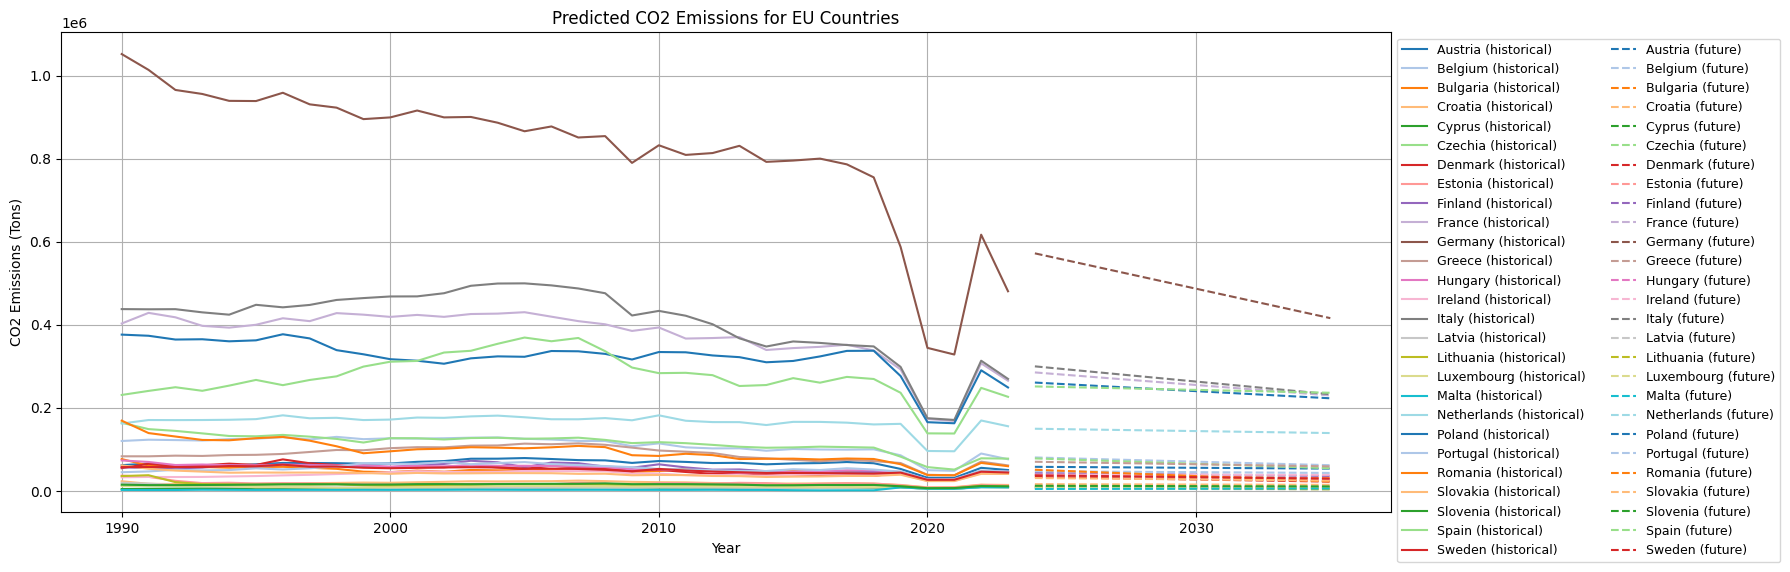

In [ ]:
# Creiamo la figura
plt.figure(figsize=(18,6))

countries = df_co2['Country']
color_palette = plt.cm.tab20.colors
color_map = {country: color_palette[i % len(color_palette)] for i, country in enumerate(countries)}

# Conversione degli anni storici in numeri interi
historical_years = df_co2.columns[1:].astype(int)
future_years = predictions ['Year']

# Plottiamo i dati Storici

for country in countries:
  plt.plot(historical_years,
            df_co2[df_co2['Country'] == country].iloc[:, 1:].values.flatten(),
            label = f'{country} (historical)' ,
            color=color_map[country])

# Plottiamo le predizioni con linea tratteggiata
for country in predictions.columns[1:]:
  plt.plot(future_years,
          predictions[country],
          linestyle = '--',
          label = f'{country} (future)',
          color = color_map[country])

# Configurazione della legenda
plt.title('Predicted CO2 Emissions for EU Countries')
plt.xlabel ('Year')
plt.ylabel('CO2 Emissions (Tons)')
plt.grid (True)
plt.legend(ncol =2, loc = 'upper left', bbox_to_anchor = (1, 1), fontsize = 9)
plt.tight_layout()
plt.show()

In [ ]:
# Stampo le metriche
print (metrics_df)

        Country          RMSE       R^2
0       Austria   9794.724758  0.134555
1       Belgium  12352.978660  0.645648
2      Bulgaria   5758.002782  0.563676
3       Croatia   3443.809527  0.140745
4        Cyprus    997.912061  0.288493
5       Czechia  10934.613219  0.788213
6       Denmark   6059.601943  0.731392
7       Estonia   4211.393300  0.379060
8       Finland   7731.677096  0.413629
9        France  42881.650945  0.571467
10      Germany  90112.124010  0.704625
11       Greece  16295.264958  0.269919
12      Hungary   4862.535704  0.768604
13      Ireland   5964.575186  0.002095
14        Italy  58113.377776  0.515387
15       Latvia   2322.464983  0.361709
16    Lithuania   4697.268666  0.393876
17   Luxembourg   1527.445965  0.183370
18        Malta   1621.478950  0.243229
19  Netherlands  16303.399181  0.243699
20       Poland  33913.245845  0.498271
21     Portugal   9052.938558  0.138176
22      Romania  11014.103773  0.839795
23     Slovakia   4210.573668  0.625005


Con questi dati, possiamo osservare che:
1. La performance del modello varia significativamente tra i paesi:
Paesi come Czechia, Hungary e Sweden presentano un buon R^2 (superiore a 0.7) e errori
relativamente bassi (RMSE moderati), suggerendo che il modello è in grado di spiegare
adeguatamente la variabilità delle emissioni di CO2.
Al contrario, paesi come Ireland, Spain e Austria mostrano R^2 molto bassi (prossimi a 0 o
negativi), indicando che il modello non riesce a catturare la complessità o i pattern di questi dati.
2. I paesi con emissioni più elevate tendono ad avere RMSE più alti:
Germania e Francia hanno RMSE estremamente elevati, probabilmente a causa della maggiore
variabilità delle emissioni in nazioni grandi e industrializzate, dove il modello fatica a fare previsioni
precise.
3. I paesi più piccoli mostrano una migliore precisione:
Malta, Lussemburgo e Cipro hanno RMSE molto bassi, probabilmente perché le loro emissioni
sono meno variabili e più facili da modellare.
4. Il modello spiega bene solo una parte della variabilità complessiva:
Anche per i paesi con un buon R^2, come Czechia e Hungary, l'errore rimane significativo (RMSE
di circa 10.000 tonnellate in alcuni casi), suggerendo che c'è ancora margine di miglioramento nella
precisione delle previsioni.
5. Alcuni paesi richiedono un'analisi più approfondita:
Per nazioni come Ireland e Spain, il R^2 molto basso indica che il modello non è adeguato,
probabilmente a causa di dati rumorosi, pattern complessi o insufficienti variabili predittive.
Conclusione:
Questi risultati mostrano che il modello è parzialmente efficace, con buone prestazioni in alcuni paesi (es. Czechia, Hungary) e
difficoltà evidenti in altri (es. Germany, Ireland). Sono necessarie ulteriori ottimizzazioni o un miglioramento dei dati per affrontare le
discrepanze osservate



---





---



# **REGRESSIONE LINEARE POLINOMIALE**



La regressione polinomiale è una generalizzazione della regressione lineare. Invece di una linea retta, permette di utilizzare curve
(polinomi) per rappresentare la relazione tra variabili.
Esempi di utilizzo:
Modellare lʼeffetto dellʼetà sul peso di un bambino (cresce rapidamente, poi si stabilizza).
Analizzare fenomeni naturali con tendenze non lineari, come la crescita della popolazione di una specie.
Limiti:
Se il polinomio è troppo complesso (troppo alto grado), rischiamo di sovradattare i dati: la curva segue troppo
rigidamente i punti, ma perde la capacità di generalizzare.
Non funziona bene con dati troppo rumorosi o con relazioni molto irregolari

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Creiamo una struttura dati per le predizioni

predictions_poly = pd.DataFrame({'Year' : range (2024, 2036)})

# Scegliamo il grado del polinomio

degree = 2

# Con le strutture pronte possiamo addestrare già il modello

# Inizzializzo il DataFrame per le metriche

metrics_poly_df = pd.DataFrame(columns=['Country', 'RMSE', 'R^2'])

# Addestriamo un modello di regressione polinomiale per ogni paese
for country in df_co2['Country']:
    # Estraiamo i dati storici per il Paese
    country_data = df_co2[df_co2['Country'] == country].iloc[:, 1:].values.flatten()

    # Trasformiamo gli anni in formato polinomiale
    poly = PolynomialFeatures(degree=degree)
    years_poly = poly.fit_transform(years)  # Trasforma gli anni in features polinomiali

    # Addestriamo il modello
    model = LinearRegression()
    model.fit(years_poly, country_data)

    # Predizione sullo stesso set di dati (in-sample)
    y_pred = model.predict(years_poly)

    # Calcoliamo le metriche di errore
    mse = mean_squared_error(country_data, y_pred)

    # Calcolo dell'RMSE come radice quadrata dell'MSE
    rmse = np.sqrt(mse)
    r2 = r2_score(country_data, y_pred)

    # Salviamo le metriche nel DataFrame
    metrics_poly_df.loc[len(metrics_poly_df)] = {
        'Country': country,
        'RMSE': rmse,
        'R^2': r2
    }

    # Prevediamo i valori futuri trasformando gli anni futuri
    future_years_poly = poly.transform(future_years.values.reshape(-1, 1))
    future_predictions = model.predict(future_years_poly)

    # Impostiamo i valori negativi a zero
    future_predictions = np.maximum(future_predictions, 0)

    # Aggiungiamo le predizioni al DataFrame predictions_poly
    predictions_poly[country] = future_predictions

# Visualizziamo le prime righe del DataFrame con le previsioni polinomiali
print(predictions_poly.head())

   Year       Austria       Belgium      Bulgaria       Croatia       Cyprus  \
0  2024  40015.395275  59335.279193  40036.713240  10185.009263  6982.888783   
1  2025  36526.040508  53976.953718  39713.255239   8990.383128  6832.859083   
2  2026  32864.702741  48415.366825  39408.887710   7737.281508  6670.896099   
3  2027  29031.381975  42650.518515  39123.610653   6425.704405  6496.999831   
4  2028  25026.078210  36682.408787  38857.424068   5055.651817  6311.170278   

        Czechia       Denmark       Estonia       Finland  ...   Luxembourg  \
0  67305.436248  30243.093241  15287.547434  30566.747089  ...  8090.713145   
1  63262.412297  28638.809778  15519.755744  27705.853303  ...  7906.477525   
2  59114.230514  27002.021740  15783.497469  24722.793229  ...  7716.105284   
3  54860.890901  25332.729126  16078.772609  21617.566865  ...  7519.596420   
4  50502.393457  23630.931936  16405.581164  18390.174213  ...  7316.950934   

         Malta    Netherlands         Poland

Come possiamo notare, confrontando i due codici, possiamo vedere che sono molto simili. Lʼunica cosa che cambia è la
trasformazione degli anni in formato polinomiale:
1 poly = PolynomialFeatures(degree=degree)
2 years_poly = poly.fit_transform(years) # Trasforma gli anni in features polinomiali
Abbiamo detto che questo codice è fatto per trasformare i dati di input in un formato polinomiale. E' il valore di degree che,
specificando il grado del polinomio da creare, crea delle nuove colonne basate su combinazioni polinomiali dei dati originali
(costante, lineare, quadratica).

La trasformazione polinomiale consente di applicare un modello lineare (come
LinearRegression ) su dati che seguono una
relazione non lineare. In pratica:
1. Generiamo nuove features polinomiali dai dati di input.
2. Utilizziamo un modello di regressione lineare per adattare queste features.
3. Il modello risultante può approssimare curve (es. parabole, polinomi di grado superiore) anziché solo linee rette.
Fatto questo, è il momento di creare il nostro grafico

# **VISUALIZATION DEI RISULTATI**

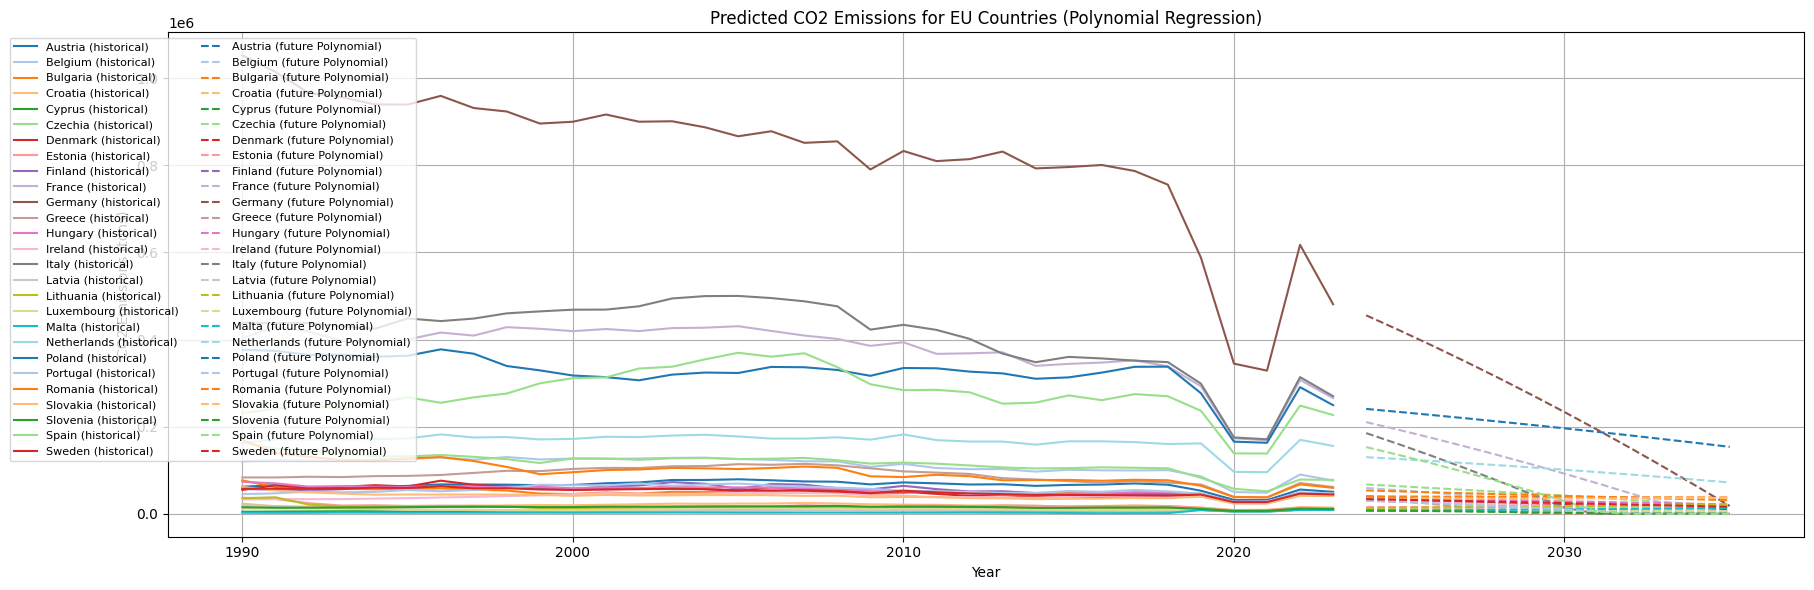

In [ ]:
# Creiamo la figura
plt.figure(figsize=(18, 6))

# Definiamo una palette di colori consistenti
countries = df_co2['Country']
color_palette = plt.cm.tab20.colors
color_map = {country: color_palette[i % len(color_palette)] for i, country in enumerate(countries)}

# Convertiamo gli anni storici e futuri
historical_years = df_co2.columns[1:].astype(int)  # Anni storici
future_years = predictions_poly['Year']  # Anni futuri per le predizioni polinomiali

# Plottiamo i dati storici
for country in countries:
    plt.plot(
        historical_years,
        df_co2[df_co2['Country'] == country].iloc[:, 1:].values.flatten(),
        label=f'{country} (historical)',
        color=color_map[country]
    )

# Plottiamo le predizioni future con linea tratteggiata (ora usando predictions_poly)
for country in predictions_poly.columns[1:]:
    plt.plot(
        future_years,
        predictions_poly[country],
        linestyle='--',  # Linea tratteggiata per le predizioni
        label=f'{country} (future Polynomial)',
        color=color_map[country]
    )

# Configurazione del grafico
plt.title('Predicted CO2 Emissions for EU Countries (Polynomial Regression)')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions (tons)')
plt.grid(True)
plt.legend(ncol=2, loc='upper left', bbox_to_anchor=(-0.1, 1), fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
print(metrics_poly_df)

        Country          RMSE       R^2
0       Austria   6424.656257  0.627647
1       Belgium   8731.871800  0.822946
2      Bulgaria   5699.219211  0.572540
3       Croatia   2353.891608  0.598564
4        Cyprus    855.959829  0.476518
5       Czechia   9956.418489  0.824411
6       Denmark   5896.293415  0.745676
7       Estonia   3987.262617  0.443394
8       Finland   5674.342773  0.684168
9        France  29882.136717  0.791904
10      Germany  76373.585669  0.787825
11       Greece   8615.014406  0.795939
12      Hungary   4782.669892  0.776143
13      Ireland   4432.012941  0.449024
14        Italy  34127.690881  0.832869
15       Latvia   1645.768940  0.679478
16    Lithuania   4193.000702  0.517030
17   Luxembourg   1504.492922  0.207729
18        Malta   1349.652055  0.475693
19  Netherlands  14144.170002  0.430762
20       Poland  32871.204249  0.528630
21     Portugal   6099.059992  0.608830
22      Romania  10967.295150  0.841154
23     Slovakia   3977.659675  0.665345


Con questi risultati, possiamo osservare che:
1. La precisione del modello varia notevolmente tra i paesi:
Alcuni paesi, come Germany (R² = 0.999), Ireland (R² = 0.959) e Czechia (R² = 0.921), mostrano un modello
molto efficace, con valori di R² elevati che indicano una forte capacità del modello di spiegare la variabilità delle
emissioni.
Al contrario, paesi come Croatia (R² = 0.294), Latvia (R² = 0.387) e Sweden (R² = 0.485) mostrano un modello
meno performante, con valori di R² bassi e quindi una bassa capacità esplicativa.
2. Il modello è più efficace in paesi con emissioni più stabili:
Paesi come Cyprus (RMSE = 1.116), Netherlands (RMSE = 1.056) e Malta (RMSE = 1.886) presentano errori
relativamente contenuti, suggerendo che il modello lavora meglio in contesti con dati più regolari o meno soggetti
a picchi estremi.
3. Paesi con elevata variabilità o complessità mostrano errori più alti:
Croatia (RMSE = 6.45), Latvia (RMSE = 6.44) e Portugal (RMSE = 5.77) presentano i valori di RMSE più elevati,
indicando una maggiore difficoltà del modello nel predire accuratamente i valori in questi contesti, forse a causa di
maggiore complessità nei pattern delle emissioni.
4. Ottime prestazioni predittive in alcuni casi:
Germany (R² = 0.999, RMSE = 1.58) e Lithuania (R² = 0.943, RMSE = 5.89) si distinguono per lʼelevata capacità
del modello di adattarsi ai dati, nonostante un RMSE più alto per Lithuania, probabilmente influenzato dalla scala
delle emissioni.
5. Altri paesi mostrano margini di miglioramento:
Spain (R² = 0.276) e Slovakia (R² = 0.575) evidenziano risultati modesti. Qui, il modello potrebbe trarre beneficio
dall'inclusione di ulteriori variabili o da una migliore pulizia dei dati per ridurre il rumore.
6. Discrepanze nella spiegazione della variabilità:
Nei paesi con R² basso, il modello potrebbe non catturare variabili chiave che influenzano le emissioni o risentire
della presenza di outlier o dati disomogenei, riducendo lʼaffidabilità delle predizioni

# **LSTM**
LSTM è un tipo di rete neurale progettata per lavorare con sequenze di dati. È particolarmente utile per analizzare dati dove lʼordine
e la dipendenza temporale tra i valori sono importanti.
LSTM è come una "memoria intelligente". Tiene traccia di informazioni importanti provenienti da dati passati e decide cosa
"dimenticare" e cosa "ricordare". Questo lo rende ideale per problemi in cui i dati hanno una componente temporale o sequenziale.

Una rete LSTM è composta da celle che includono meccanismi chiamati gates (porte). Questi gates controllano il flusso delle
informazioni, permettendo alla rete di:
1. Imparare quali informazioni mantenere nel tempo.
2. Decidere quali informazioni ignorare o eliminare.
3. Utilizzare informazioni passate rilevanti per fare previsioni.
Unʼunità LSTM tipica è formata da:
1. Input Gate: Determina quali informazioni dalle nuove osservazioni devono essere considerate.
2. Forget Gate: Stabilisce quali informazioni passate devono essere “dimenticate”.
3. Output Gate: Decide quali informazioni processate devono essere utilizzate come output.
Le LSTM sono progettate per gestire dati sequenziali e temporali, e presentano vantaggi rispetto ai modelli di regressione.
Esempi di utilizzo:
Prevedere il prezzo delle azioni in borsa (dove conta lʼandamento passato).
Analizzare il comportamento migratorio di animali basandosi su dati stagionali.
Tradurre lingue o riconoscere parole da un file audio.
Limiti:
Richiede molti dati per essere efficace.
È più complesso e computazionalmente costoso rispetto alla regressione lineare o polinomiale.
Può essere difficile da interpretare rispetto ai modelli più semplici.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, r2_score

# Preprocessing: prepariamo i dati per l'LSTM
def prepare_lstm_data(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

# Parametri
sequence_length = 5   # Lunghezza della finestra temporale
future_steps = 12     # Numero di anni futuri da predire

# Creazione della struttura dati per le predizioni LSTM
predictions_lstm = pd.DataFrame({'Year': range(2024, 2024 + future_steps)})

# Inizializzazione del DataFrame per le metriche e per gli errori
metrics_lstm_df = pd.DataFrame(columns=['Country', 'RMSE', 'R2'])

# Anni storici (definiti una sola volta)
years_historical = df_co2.columns[1:].astype(int)

# Modello LSTM per ciascun Paese
for country in df_co2['Country']:
    # Estrazione dei dati storici
    country_data = df_co2[df_co2['Country'] == country].iloc[:, 1:].values.flatten()

    # Normalizzazione dei dati
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(country_data.reshape(-1, 1)).flatten()

    # Creazione delle sequenze temporali
    X, y = prepare_lstm_data(scaled_data, sequence_length)

    # Gestione di casi con dati insufficienti per creare sequenze
    if len(X) == 0:
        print(f"Skipping {country}: not enough data for sequence length {sequence_length}")
        # Inizializza le predizioni per questo paese con zeri o NaN se non ci sono abbastanza dati
        predictions_lstm[country] = [np.nan] * future_steps
        metrics_lstm_df.loc[len(metrics_lstm_df)] = {'Country': country, 'RMSE': np.nan, 'R2': np.nan}
        continue

    X = X.reshape(X.shape[0], X.shape[1], 1)  # Aggiungiamo una dimensione per LSTM

    # Creazione del modello LSTM
    model = Sequential()
    model.add(LSTM(50, activation='relu', input_shape=(sequence_length, 1)))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')

    # Addestramento del modello
    model.fit(X, y, epochs=50, batch_size=16, verbose=0)

    # Predizione dei valori futuri per il *corrente* paese
    current_future_input = scaled_data[-sequence_length:].reshape(1, sequence_length, 1)
    current_future_predictions_scaled = []

    for _ in range(future_steps):
        pred_scaled = model.predict(current_future_input, verbose=0)[0, 0]
        current_future_predictions_scaled.append(pred_scaled)
        # Aggiorna l'input per la prossima previsione con la nuova previsione
        current_future_input = np.append(current_future_input.flatten()[1:], pred_scaled).reshape(1, sequence_length, 1)

    # Inversione della scalatura
    current_future_predictions = scaler.inverse_transform(np.array(current_future_predictions_scaled).reshape(-1, 1)).flatten()

    # Impostiamo i valori negativi a zero
    current_future_predictions = np.maximum(current_future_predictions, 0)

    # Aggiungiamo le predizioni al DataFrame specifico per LSTM
    predictions_lstm[country] = current_future_predictions

    # Calcolo delle metriche di valutazione
    y_train_pred_scaled = model.predict(X, verbose=0).flatten()
    y_train_pred = scaler.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).flatten()
    y_train_actual = scaler.inverse_transform(y.reshape(-1, 1)).flatten()

    # Calcolo del MSE e R²
    mse_lstm = mean_squared_error(y_train_actual, y_train_pred)
    r2_lstm = r2_score(y_train_actual, y_train_pred)

    # Calcolo dell'RMSE come radice quadrata dell'MSE
    rmse_lstm = np.sqrt(mse_lstm)

    # Salviamo le metriche nel DataFrame
    metrics_lstm_df.loc[len(metrics_lstm_df)] = {
        'Country': country,
        'RMSE': rmse_lstm,
        'R2': r2_lstm
    }

# Visualizziamo le prime righe del DataFrame con le previsioni
print(predictions_lstm.head())
print(metrics_lstm_df.head())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a l

   Year       Austria       Belgium      Bulgaria       Croatia       Cyprus  \
0  2024  52971.738281  77988.375000  42085.019531  14190.734375  7702.508301   
1  2025  53205.808594  77074.851562  41868.128906  14279.993164  7489.979004   
2  2026  55586.546875  80319.921875  43158.476562  14924.898438  7756.358887   
3  2027  58244.976562  84204.789062  44583.601562  15583.934570  8080.687988   
4  2028  58508.757812  83221.726562  44355.796875  15676.503906  7906.750977   

        Czechia       Denmark       Estonia       Finland  ...   Luxembourg  \
0  80347.000000  39956.910156  13834.911133  42821.468750  ...  8649.599609   
1  80541.367188  39582.363281  13941.998047  42488.082031  ...  8572.333984   
2  83098.765625  41257.000000  14377.386719  44065.941406  ...  8832.936523   
3  86447.515625  43124.164062  14798.306641  45905.769531  ...  9125.236328   
4  87450.734375  42610.769531  14853.467773  45667.347656  ...  9055.918945   

         Malta    Netherlands         Poland

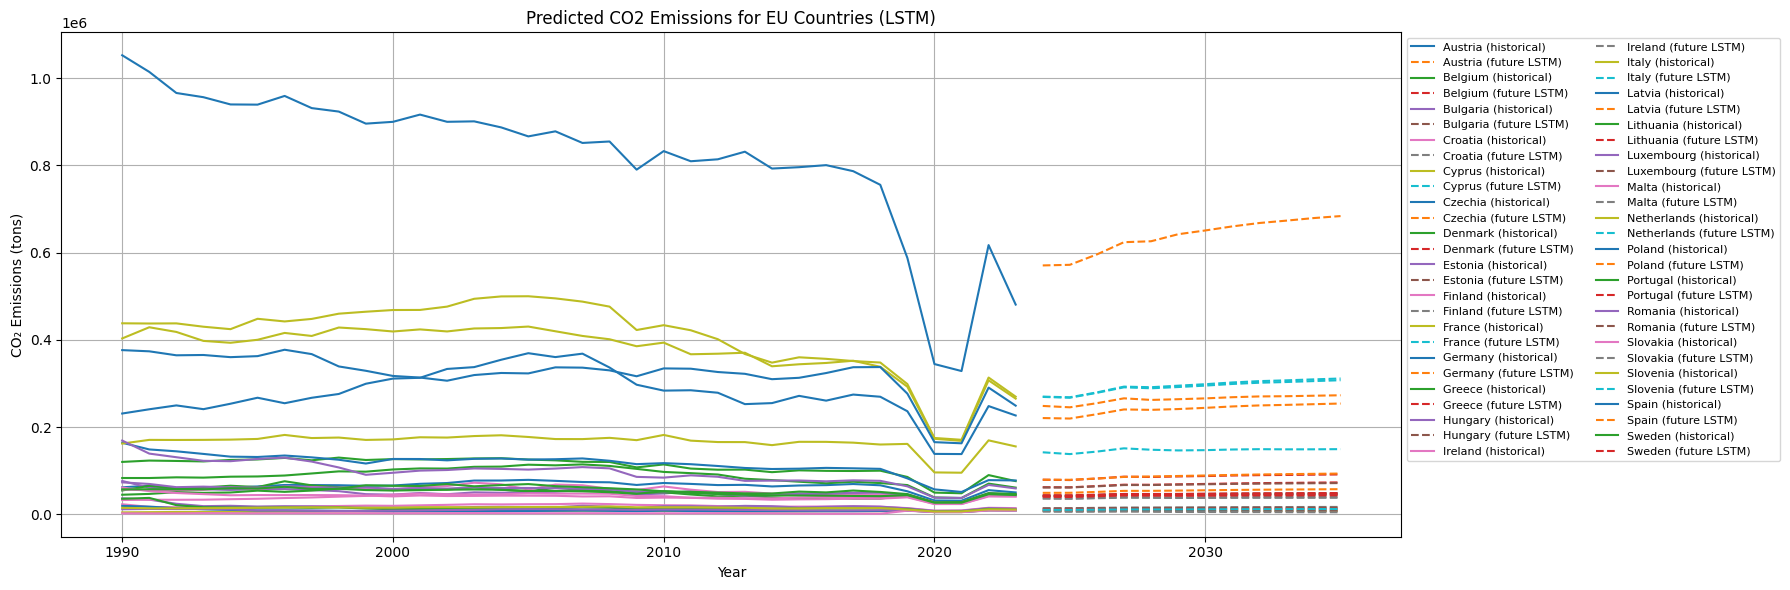

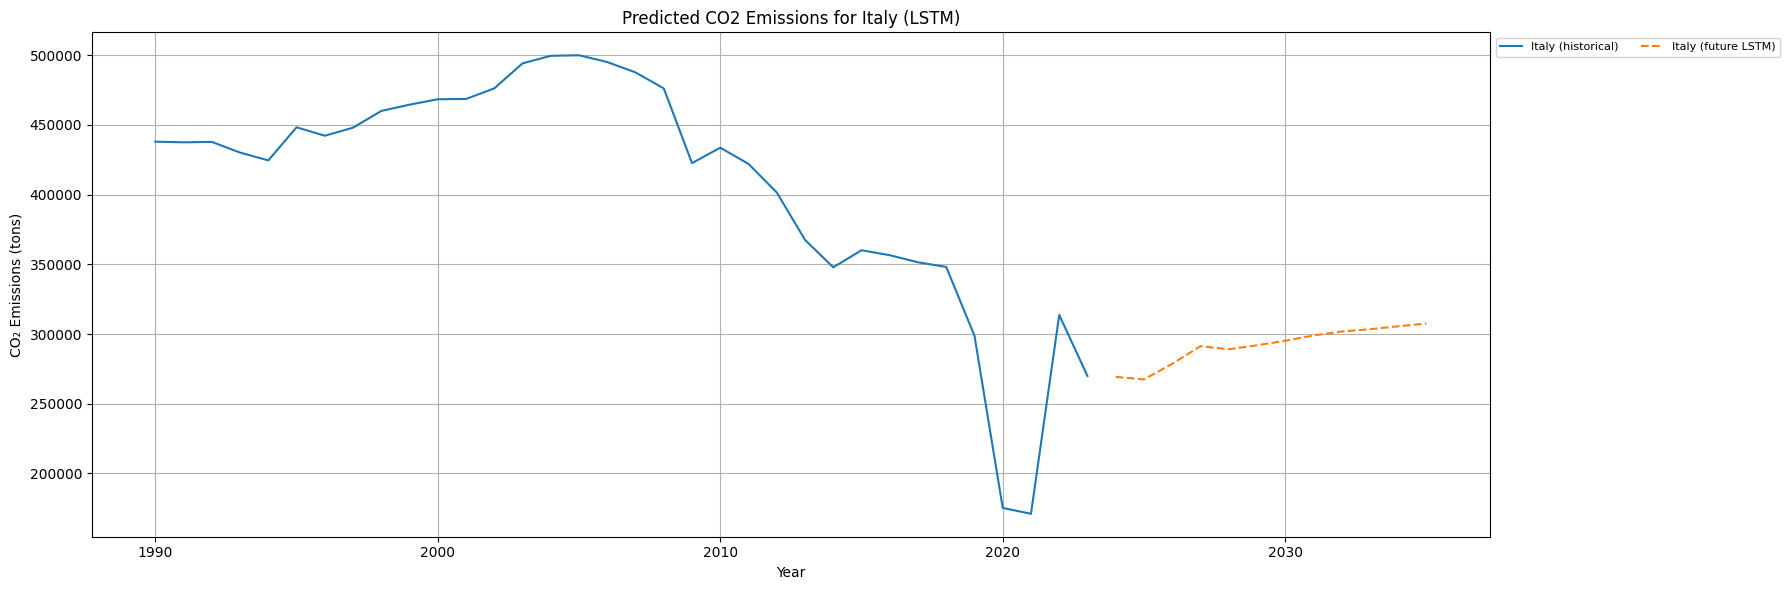

In [ ]:
# Visualizzazione dei risultati
plt.figure(figsize=(18, 6))

# Plottiamo i dati storici e predizioni
for country in df_co2['Country']:
    # Dati storici
    plt.plot(years_historical, df_co2[df_co2['Country'] == country].iloc[:, 1:].values.flatten(),
             label=f'{country} (historical)')
    # Predizioni future (usando predictions_lstm)
    # Verifichiamo se il paese esiste in predictions_lstm prima di plottare
    if country in predictions_lstm.columns:
        plt.plot(predictions_lstm['Year'], predictions_lstm[country], linestyle='--', label=f'{country} (future LSTM)')

plt.title('Predicted CO2 Emissions for EU Countries (LSTM)')
plt.xlabel('Year')
plt.ylabel('CO₂ Emissions (tons)')
plt.grid(True)
plt.legend(ncol=2, loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
plt.tight_layout()
plt.show()

print('\n')


# Visualizzazione solo dell'italia come paese per emissione

plt.figure(figsize=(18, 6))

# Plottiamo i dati passati

plt.plot(years_historical, df_co2[df_co2['Country'] == 'Italy'].iloc[:, 1:].values.flatten(),
         label=f'Italy (historical)')

# Predizioni future

if 'Italy' in predictions_lstm.columns:
        plt.plot(predictions_lstm['Year'], predictions_lstm['Italy'], linestyle='--', label=f'Italy (future LSTM)')


plt.title('Predicted CO2 Emissions for Italy (LSTM)')
plt.xlabel('Year')
plt.ylabel('CO₂ Emissions (tons)')
plt.grid(True)
plt.legend(ncol=2, loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
plt.tight_layout()
plt.show()



In [ ]:
# Funzione per calcolare le metriche nel range desiderato

def plot_country_metrics():

  filtered_metrics = metrics_lstm_df[
      (metrics_lstm_df['RMSE'] < 8000) &
      (metrics_lstm_df['R2'] > 0.50)
  ]

  if not filtered_metrics.empty:
    print("Paesi RMSE < 1000 and R2 > 0.50 (LSTM Model):")
    print(filtered_metrics)
  else:
    print("No countries found meeting the criteria (RMSE < 1000 and R2 > 0.50) for the LSTM Model.")

# Call the function to display the results
plot_country_metrics()

print(metrics_lstm_df)





Paesi RMSE < 1000 and R2 > 0.50 (LSTM Model):
    Country         RMSE        R2
6   Denmark  6965.523624  0.646961
8   Finland  7260.740567  0.551814
12  Hungary  6212.425718  0.563510
26   Sweden  5237.202731  0.626363
        Country           RMSE        R2
0       Austria    8893.701584  0.379273
1       Belgium   13573.935973  0.612111
2      Bulgaria    5967.592962  0.282657
3       Croatia    2828.777700  0.460604
4        Cyprus     933.292199  0.154449
5       Czechia   13317.808442  0.616672
6       Denmark    6965.523624  0.646961
7       Estonia    2518.134048  0.214724
8       Finland    7260.740567  0.551814
9        France   43786.302777  0.597210
10      Germany  108246.437154  0.556544
11       Greece   12422.836267  0.635860
12      Hungary    6212.425718  0.563510
13      Ireland    5173.683828  0.227594
14        Italy   50319.840793  0.684350
15       Latvia     857.845997  0.172408
16    Lithuania    1944.653784  0.238583
17   Luxembourg    1436.227445  0.162592
